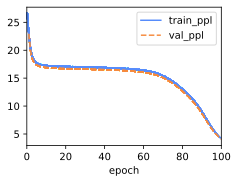

In [3]:
# 构造双向 LSTM：同时从正向和反向读取序列信息。
import torch
from torch import nn
from d2l import torch as d2l

# 加载数据
batch_size, num_steps, device = 32, 35, d2l.try_gpu()
data = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)
train_iter = data.train_dataloader()
vocab = data.vocab
# 通过设置“bidirective=True”来定义双向LSTM模型
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers, bidirectional=True)
model = d2l.RNNLM(lstm_layer, len(vocab))
model = model.to(device)
# 训练模型
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)
